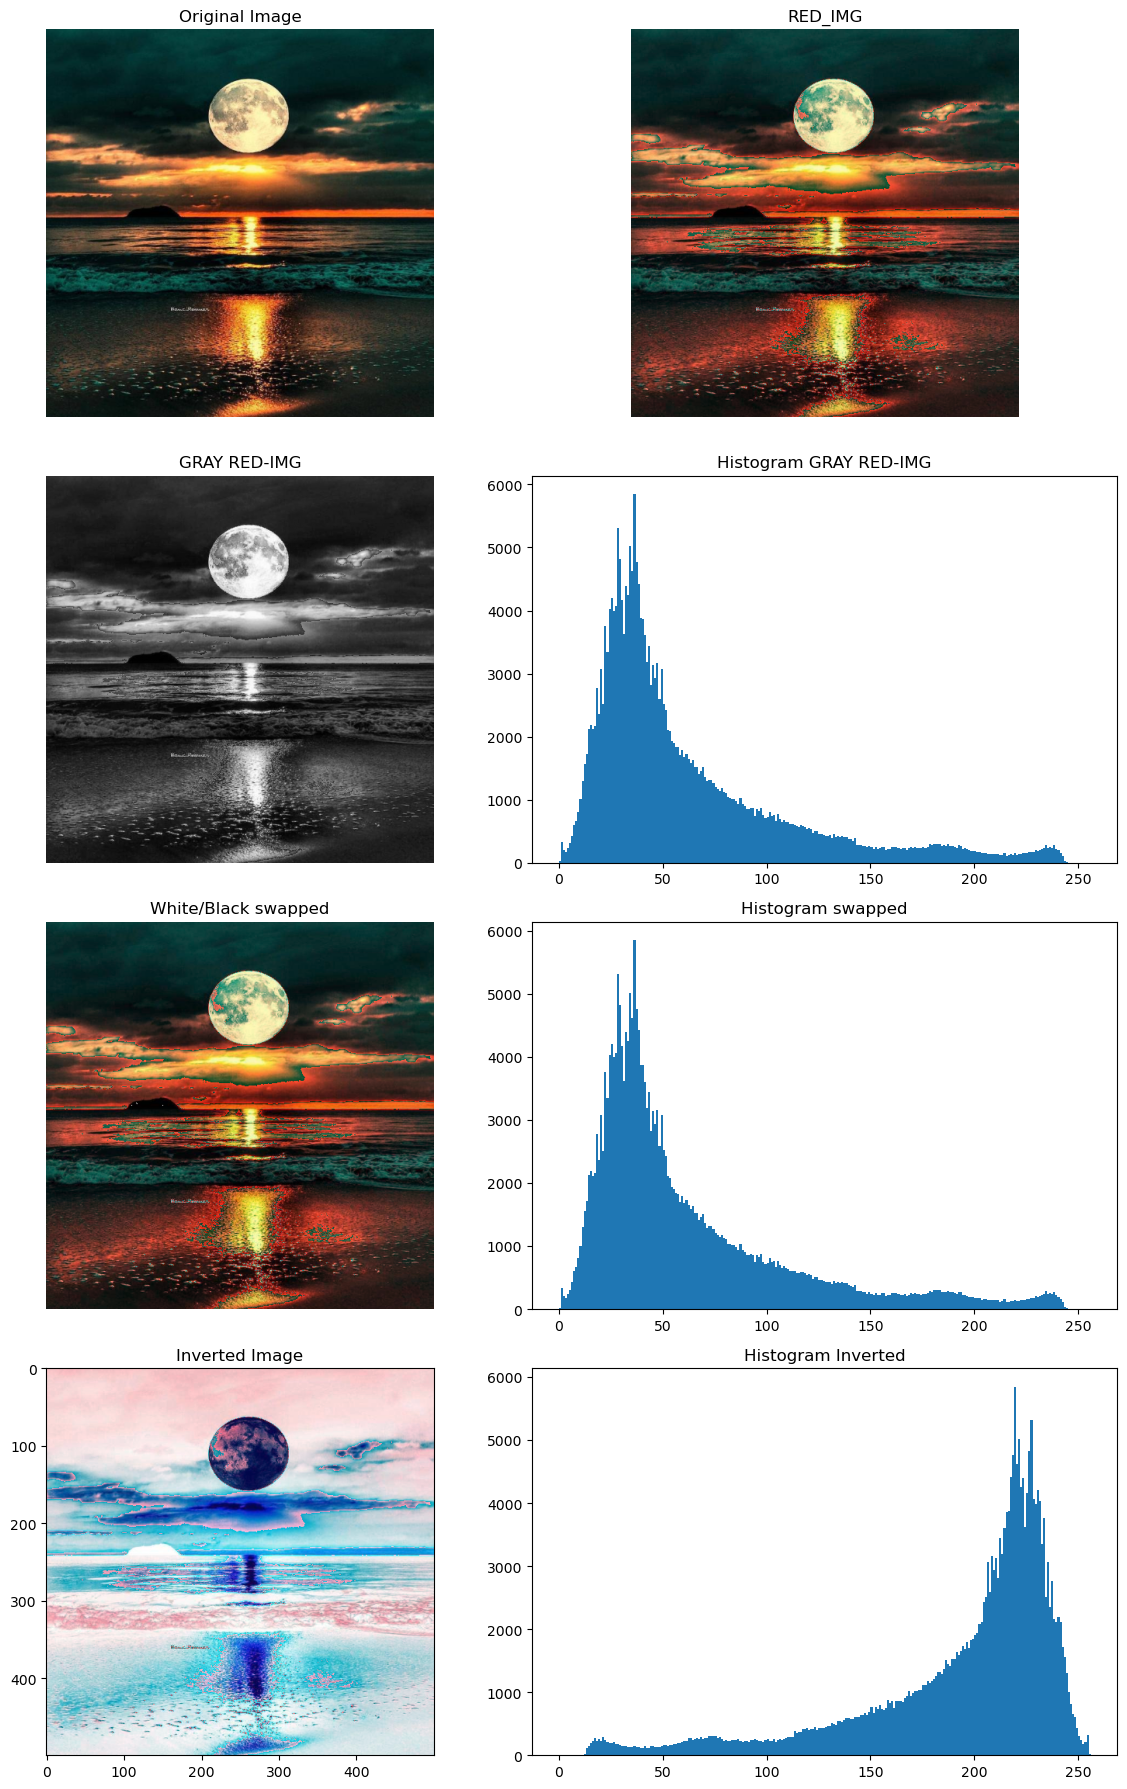

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



class ImageProcessor:
    def __init__(self, img_path):
        self.img = cv2.imread(img_path)
        self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
        self.img = cv2.resize(self.img, (500,500))


    def get_grayscale(self, image):
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    def process_red(self):
        img_red = self.img.copy()
        img_red[:,:,0] = np.clip(img_red[:,:,0] * 2,0, 255)
        return img_red

    def swap_black_white(self, image):

        img = image.copy()
        white_mask = np.all(img == [255,255,255], axis = 2) 
        black_mask = np.all(img == [0,0,0] , axis = 2)
        img[white_mask] = [0,0,0]
        img[black_mask] = [255,255,255]
        return img
        
    def invert_histogram(self,image):
        return 255 - image

    def run_all(self):
        img_red = self.process_red()
        gray_red = self.get_grayscale(img_red)
        swapped_img = self.swap_black_white(img_red)
        inverted_img = self.invert_histogram(img_red)

        fig, axs = plt.subplots(4,2, figsize=(12,18))
        
        axs[0,0].imshow(self.img)
        axs[0,0].set_title("Original Image")
        axs[0,0].axis("off")
        axs[0,1].imshow(img_red)
        axs[0,1].set_title("RED_IMG")
        axs[0,1].axis("off")

        axs[1,0].imshow(gray_red, cmap='gray')
        axs[1,0].set_title("GRAY RED-IMG")
        axs[1,0].axis("off")
        axs[1,1].hist(gray_red.ravel(),bins = 256,range = [0,256])
        axs[1,1].set_title("Histogram GRAY RED-IMG")

        axs[2,0].imshow(swapped_img)
        axs[2,0].set_title("White/Black swapped")
        axs[2,0].axis("off")
        axs[2,1].hist(self.get_grayscale(swapped_img).ravel(),bins=256, range=[0,256])
        axs[2,1].set_title("Histogram swapped")

        axs[3,0].imshow(inverted_img)
        axs[3,0].set_title("Inverted Image")
        axs[3,1].hist(self.get_grayscale(inverted_img).ravel(), bins=256, range=[0,256])
        axs[3,1].set_title("Histogram Inverted")
      
        plt.tight_layout() 
        plt.show()
        
img_path = "dl2.jpg"      
obj = ImageProcessor("dl2.jpg")
if obj.img is not None:
    obj.run_all()
        